In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 5000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


# PVFM - RF - Oracle

1000
1000 train done
1.5771420246698307


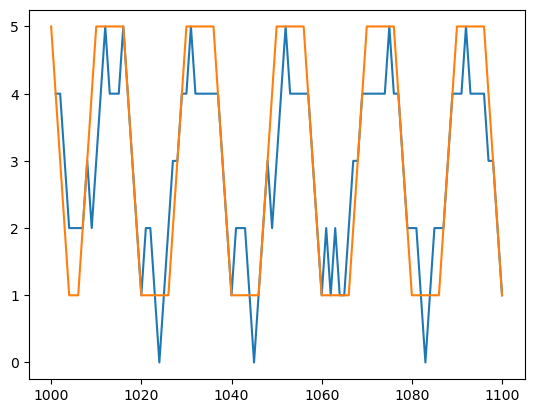

5000
5000 train done
1.6657624839170182


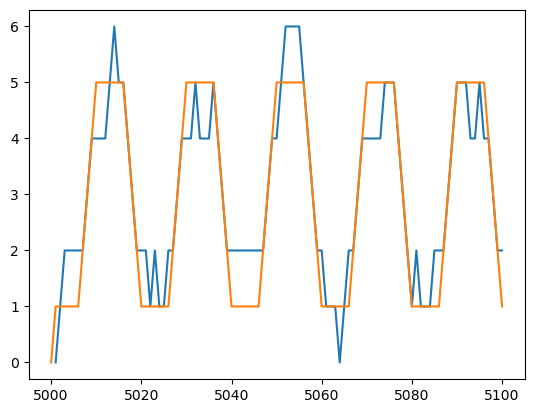

10000
10000 train done
1.157565567772829


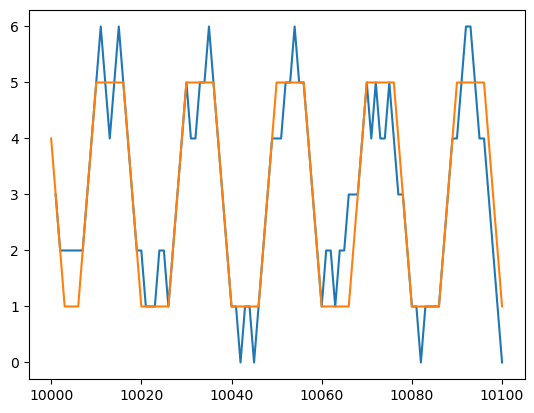

20000
20000 train done
1.3479788660746608


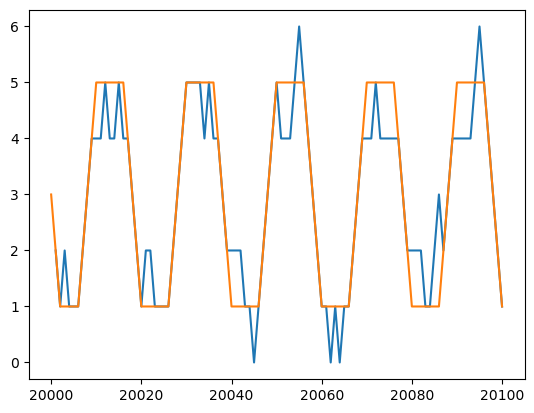

40000
40000 train done
0.9448973163970564


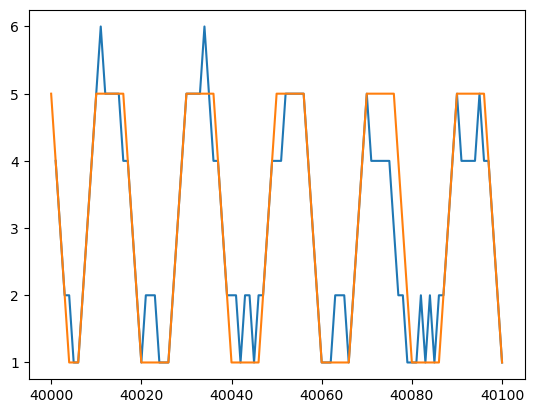

80000
80000 train done
1.3303488297048602


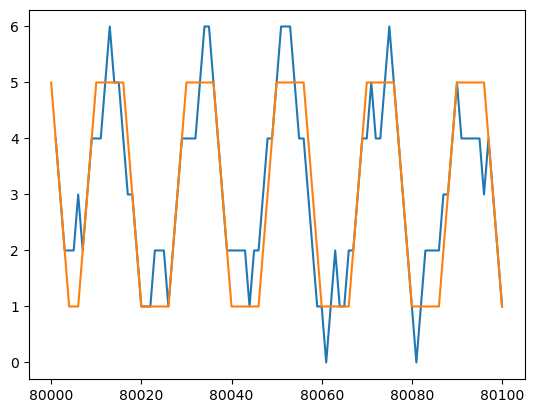

160000
160000 train done
0.982327336331864


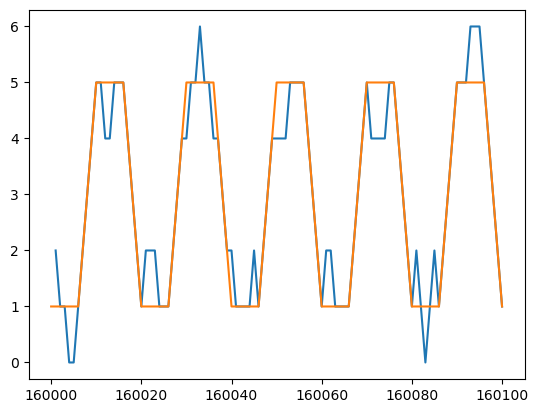

320000
320000 train done
1.3351055084889385


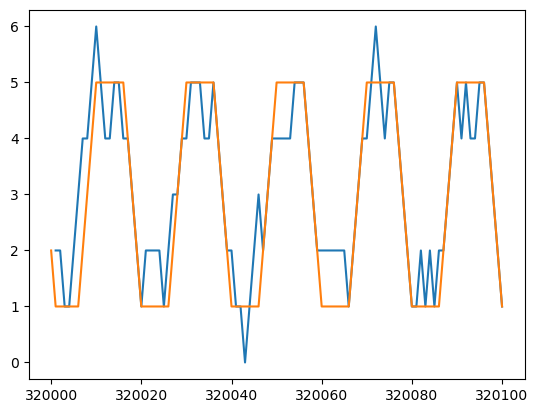

640000
640000 train done
1.2906405199455526


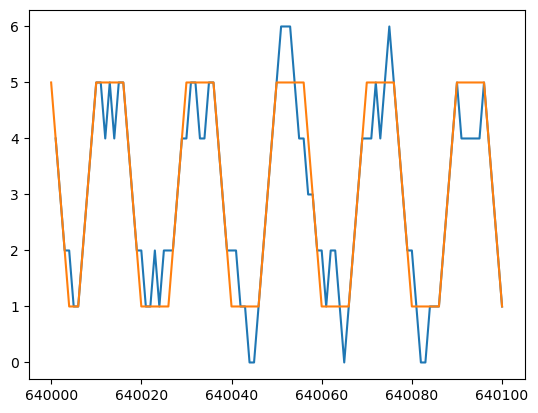

1000
1000 train done
1.6838016702597414


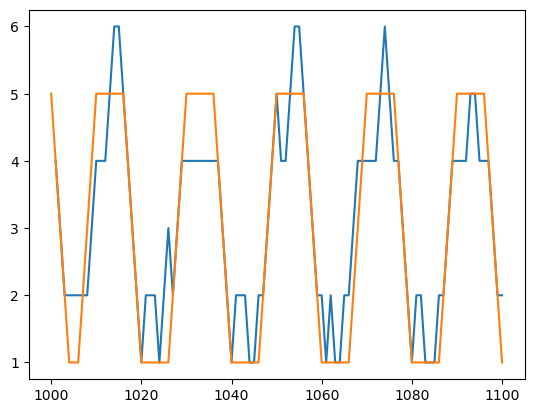

5000
5000 train done
1.2773082138878147


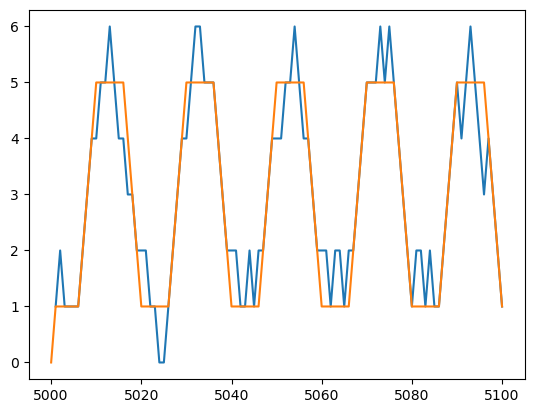

10000
10000 train done
1.0861647471905533


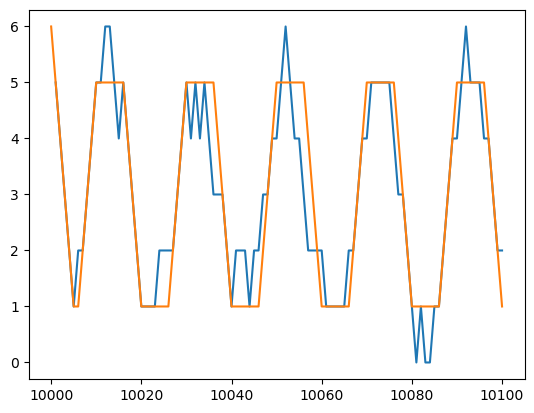

20000
20000 train done
1.2665811991638642


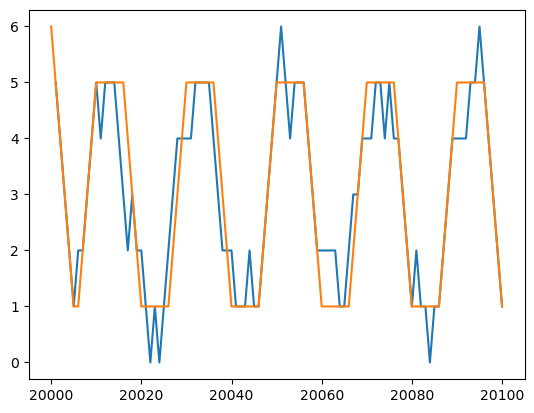

40000
40000 train done
1.4063539690652325


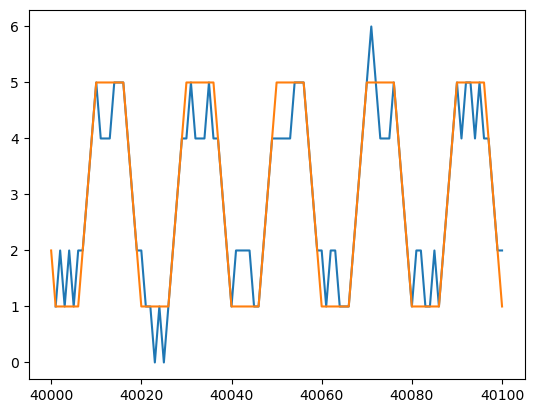

80000
80000 train done
1.2533021505429847


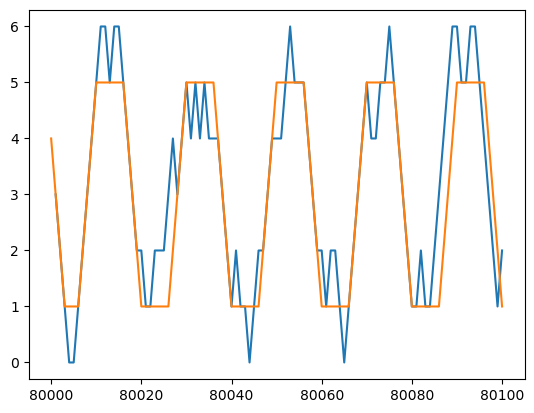

160000
160000 train done
1.4591264142386726


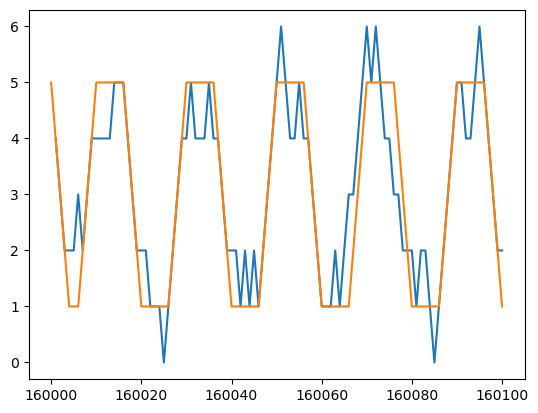

320000
320000 train done
1.3776921565581848


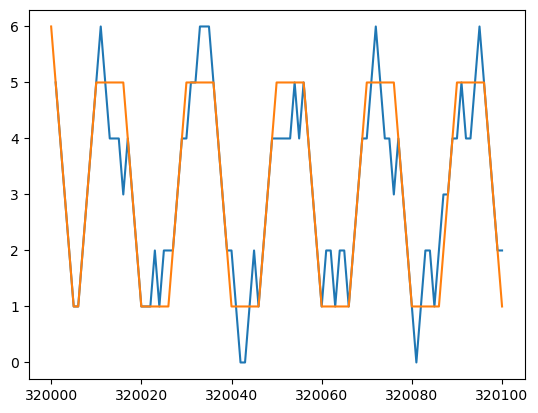

640000
640000 train done
1.0747999306122877


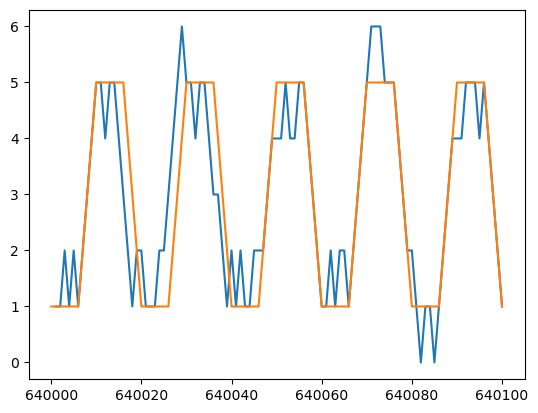

1000
1000 train done
1.1117215274486698


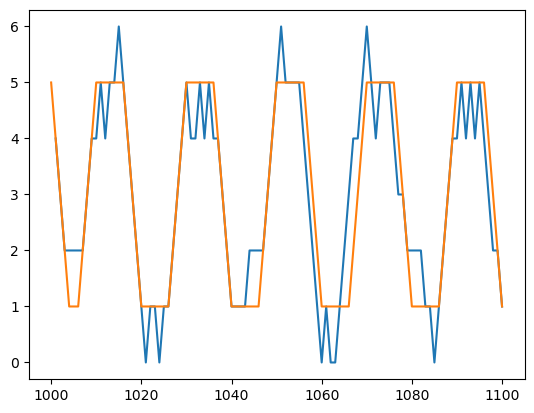

5000
5000 train done
1.4481967305302572


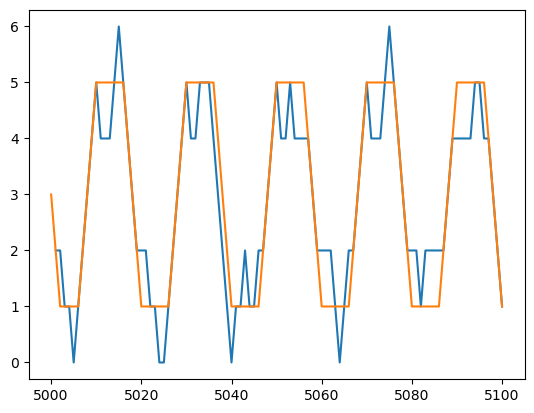

10000
10000 train done
1.406320125972095


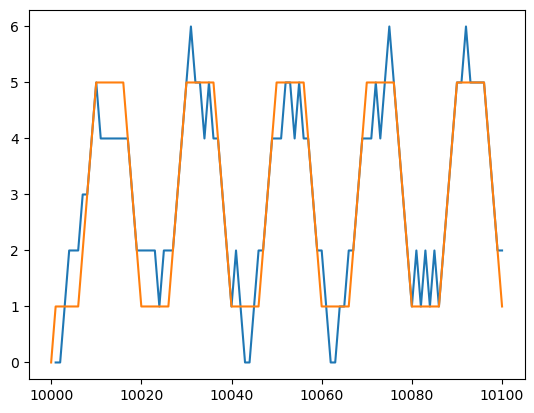

20000
20000 train done
1.355571496668319


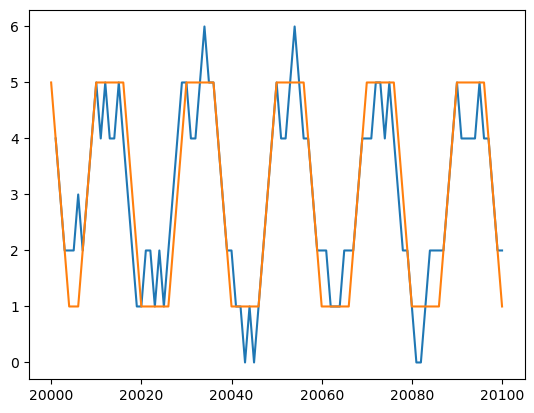

40000
40000 train done
1.564572742775358


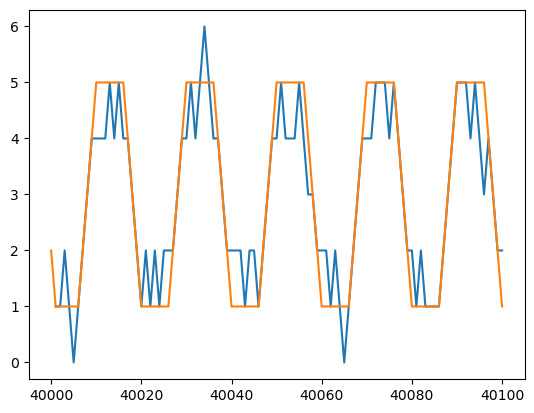

80000
80000 train done
1.2204268681071953


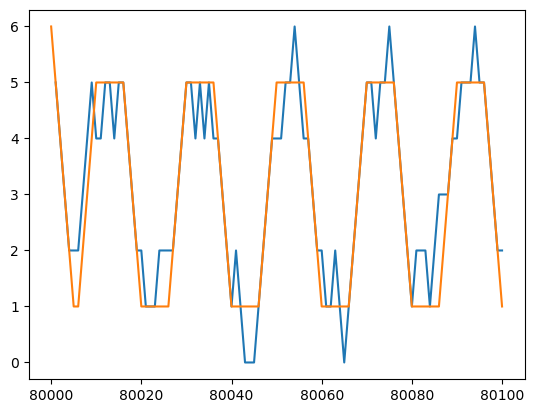

160000
160000 train done
1.4636886742469672


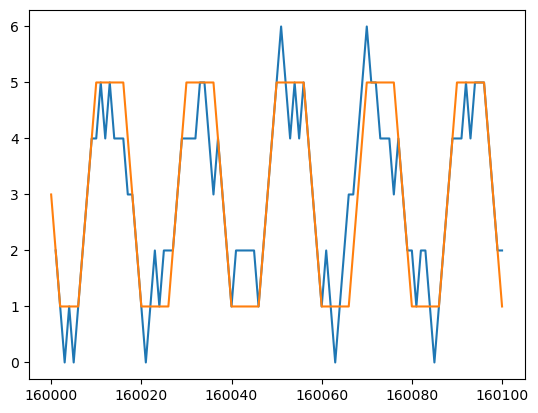

320000
320000 train done
1.1035726895353104


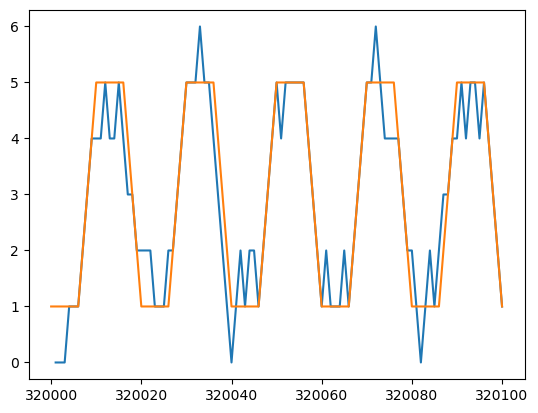

640000
640000 train done
1.565427245402214


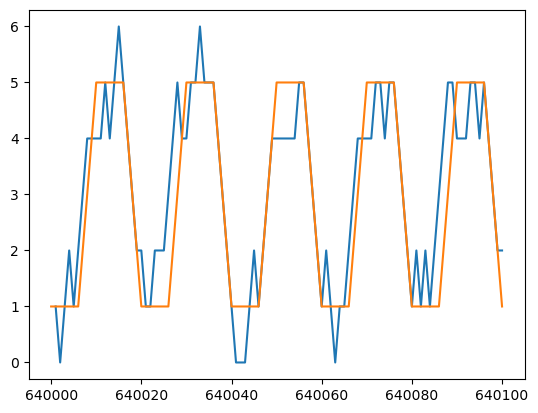

1000
1000 train done
1.3264240980964253


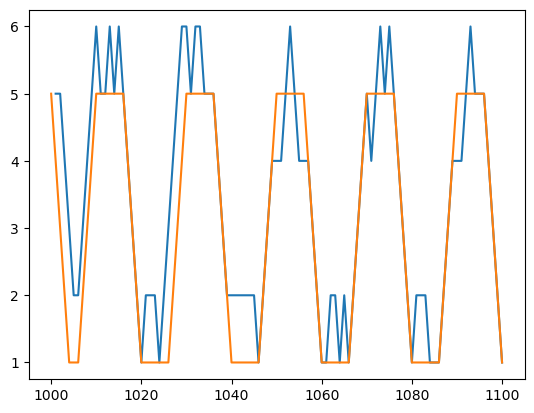

5000
5000 train done
1.52339708308634


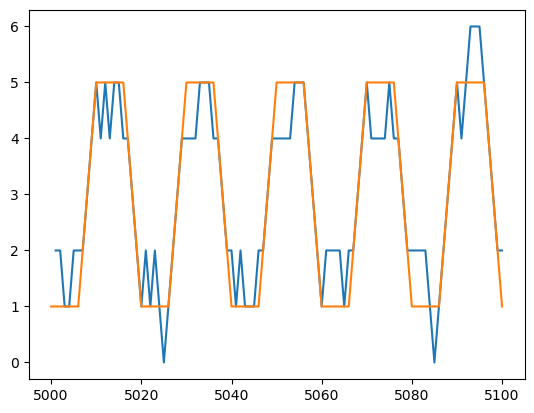

10000
10000 train done
1.4238024363312158


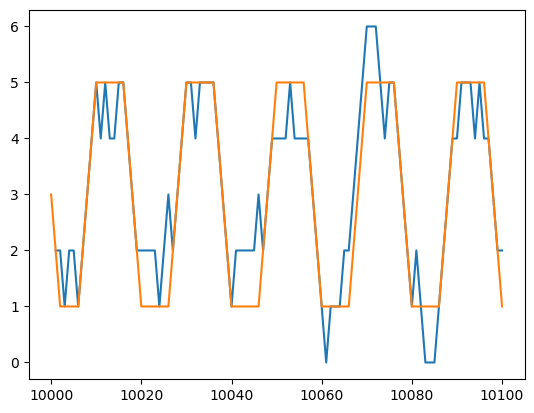

20000
20000 train done
1.4054900493410583


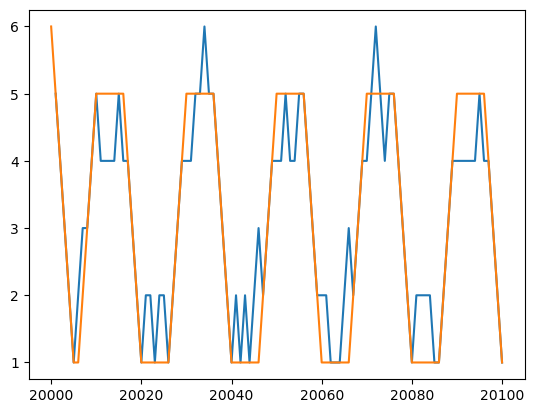

40000
40000 train done
1.3109146689267666


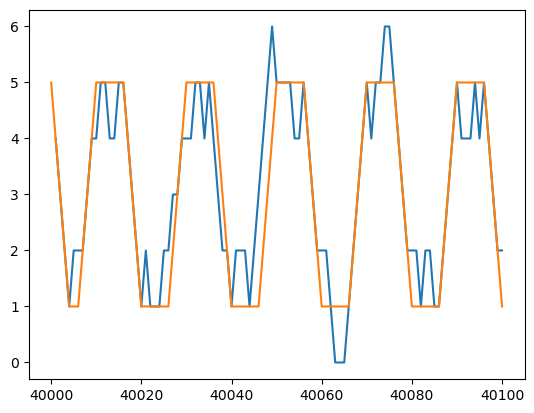

80000
80000 train done
1.1931123819944531


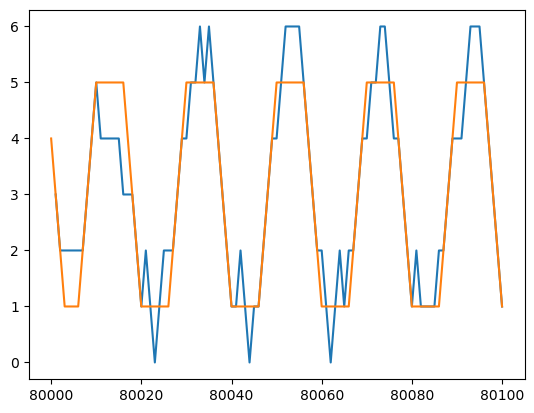

160000
160000 train done
1.2904630495144742


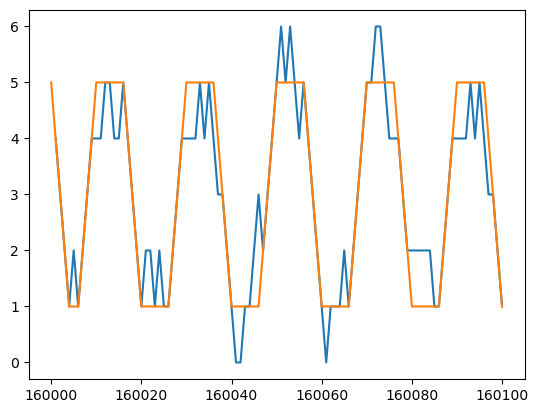

320000
320000 train done
1.3105458533082228


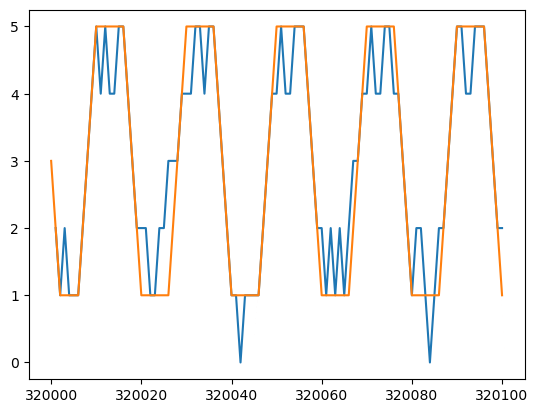

640000
640000 train done
1.1210879196675683


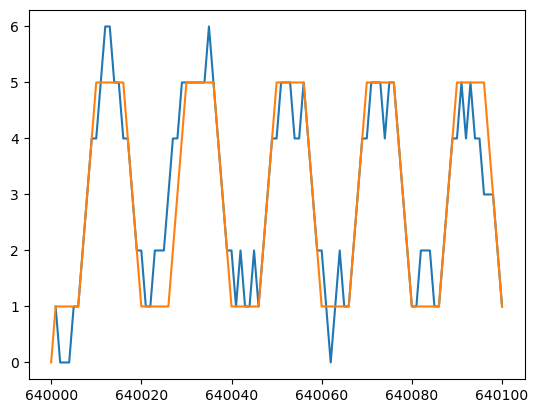

1000
1000 train done
1.7641075980412488


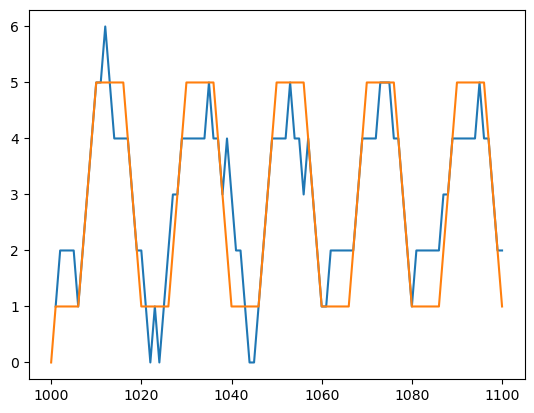

5000
5000 train done
1.5121987266340984


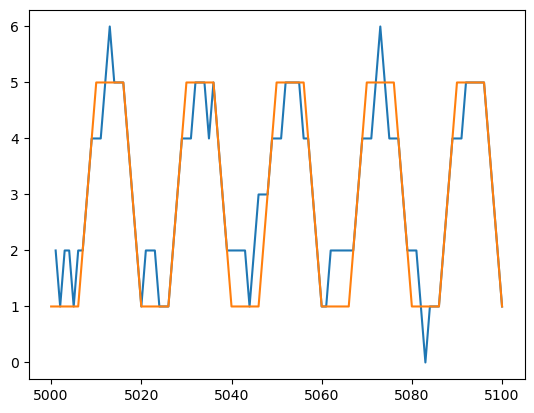

10000
10000 train done
1.6480655885113134


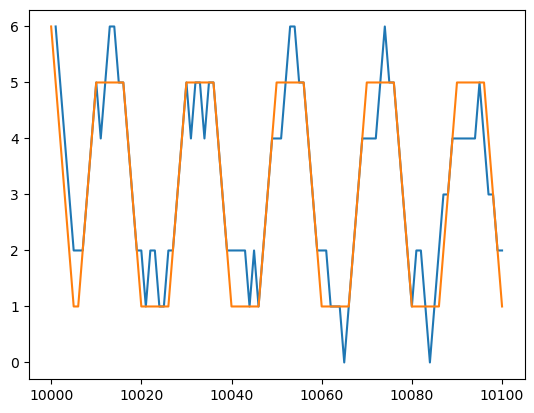

20000
20000 train done
1.5131884403138753


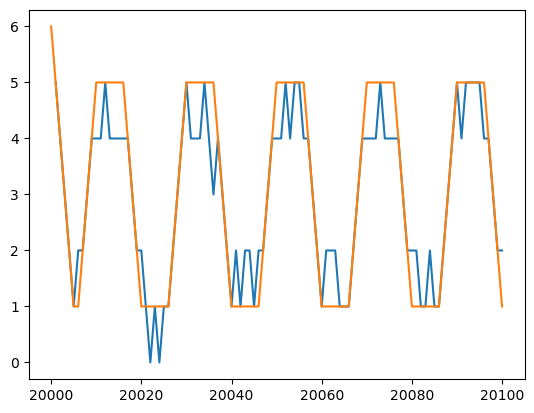

40000
40000 train done
1.3192314103527933


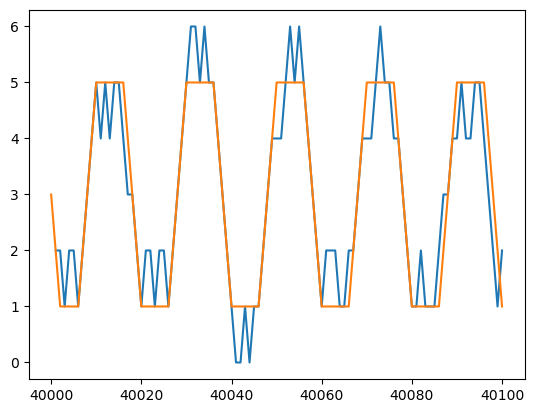

80000
80000 train done
1.0885348856135084


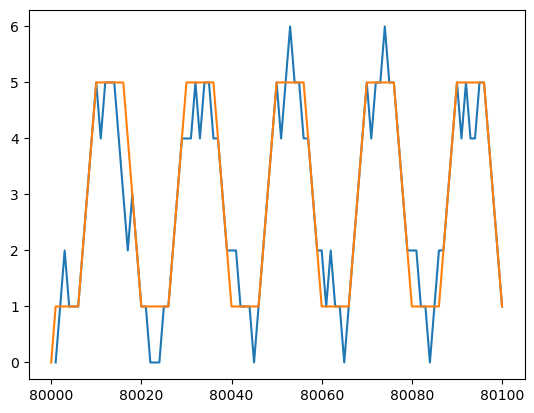

160000
160000 train done
1.1524711556647518


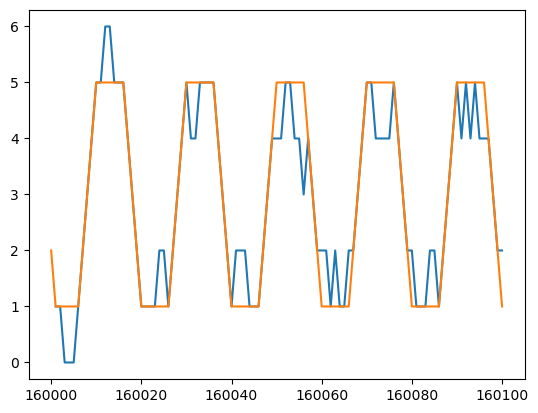

320000
320000 train done
1.0156629305657532


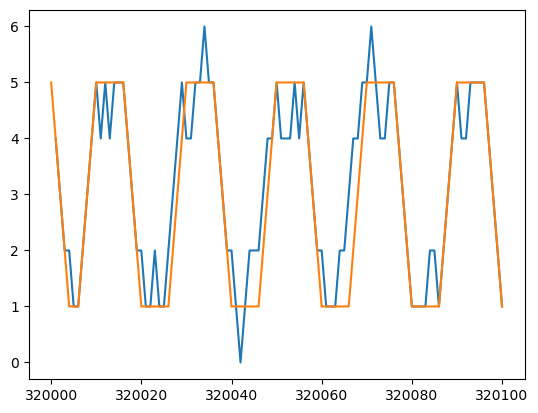

640000
640000 train done
1.263753058772646


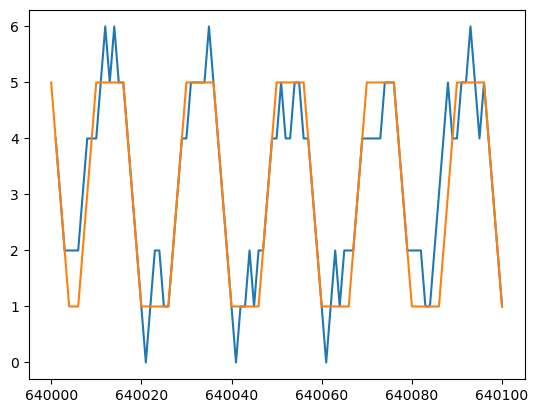

1000
1000 train done
1.3210290247002785


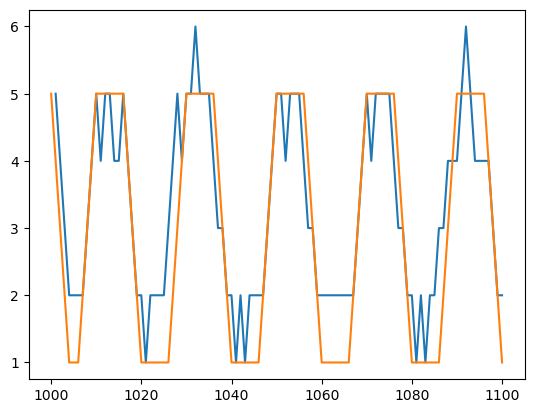

5000
5000 train done
1.7754655105302322


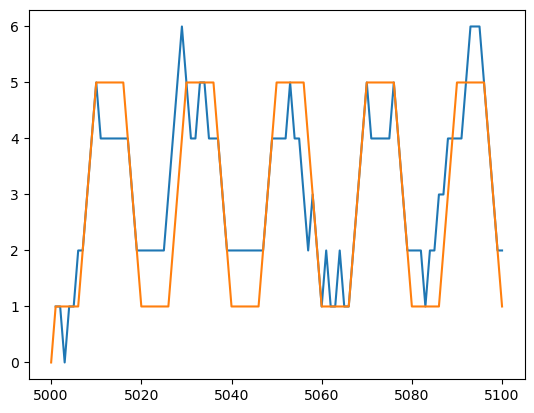

10000
10000 train done
1.0496838545039193


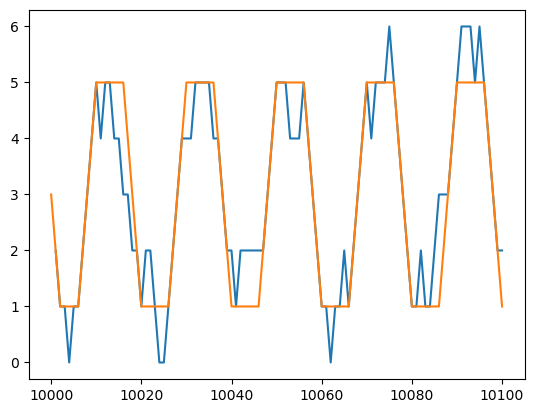

20000
20000 train done
1.5689866914374673


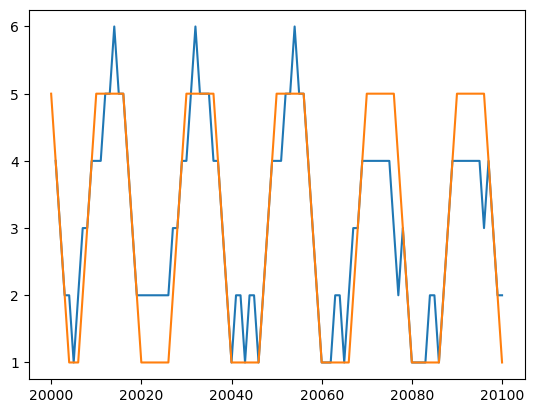

40000
40000 train done
1.6493796153709963


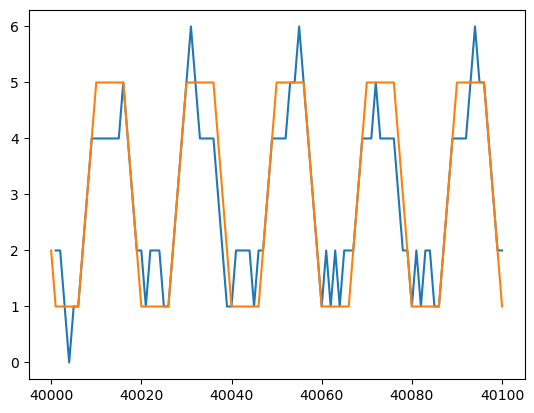

80000
80000 train done
1.4909320860934587


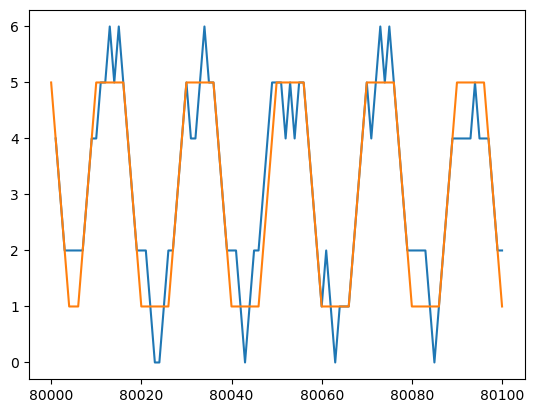

160000
160000 train done
1.6357562502315506


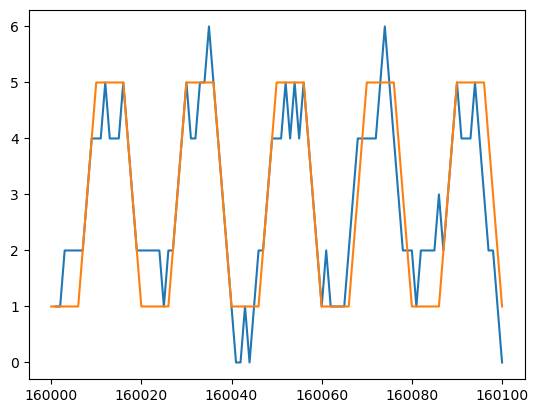

320000
320000 train done
1.4615874179755237


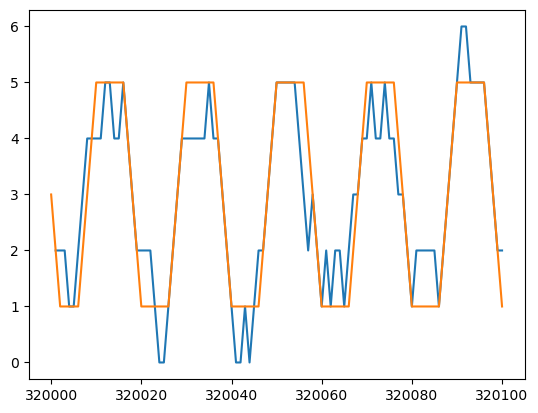

640000
640000 train done
1.2492386257046593


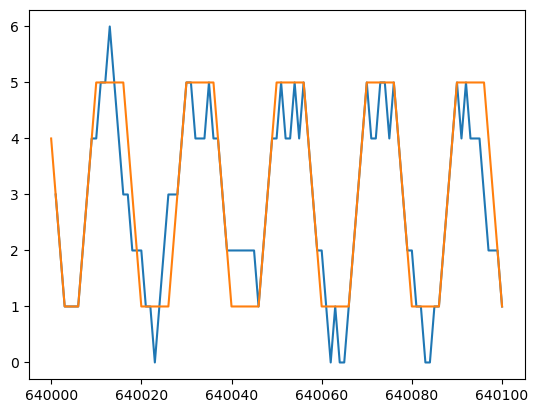

1000
1000 train done
1.974048001222163


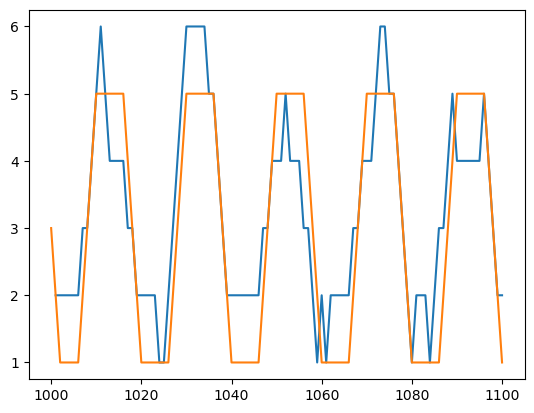

5000
5000 train done
1.2525677995890363


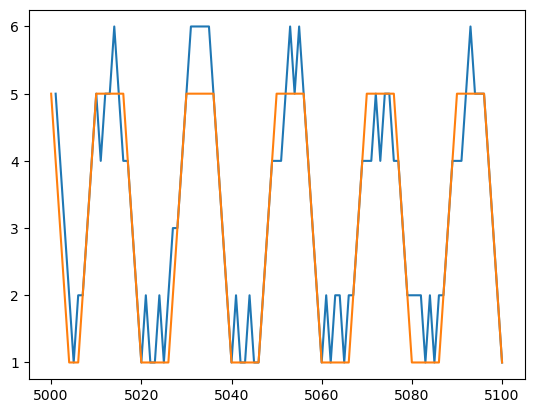

10000
10000 train done
2.056011292781597


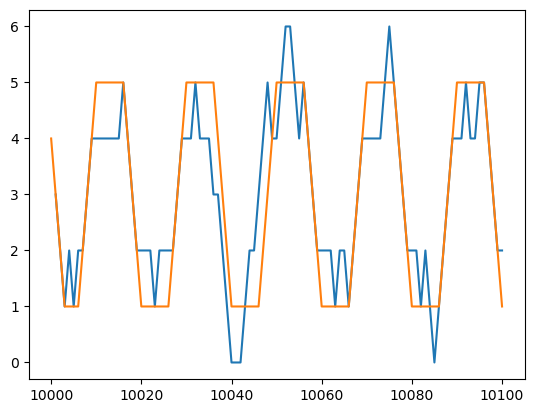

20000
20000 train done
1.4832249832475586


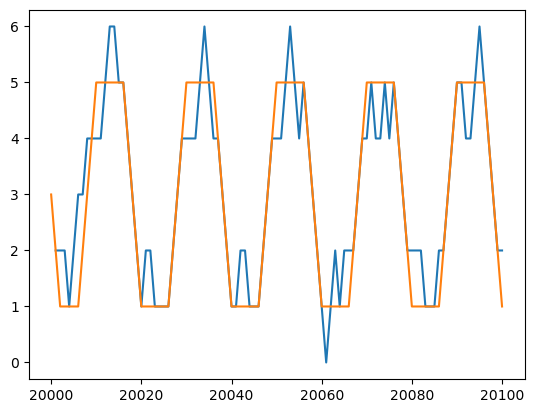

40000
40000 train done
1.2146401795677066


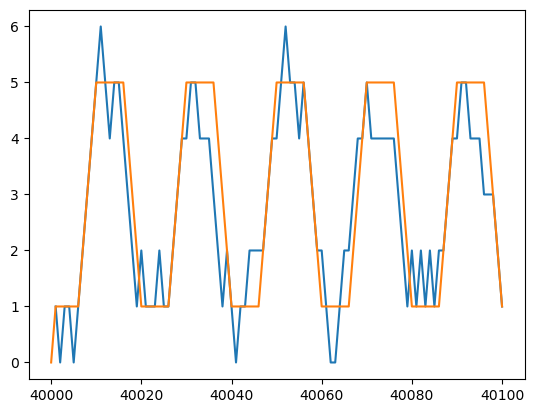

80000
80000 train done
1.3583315470257156


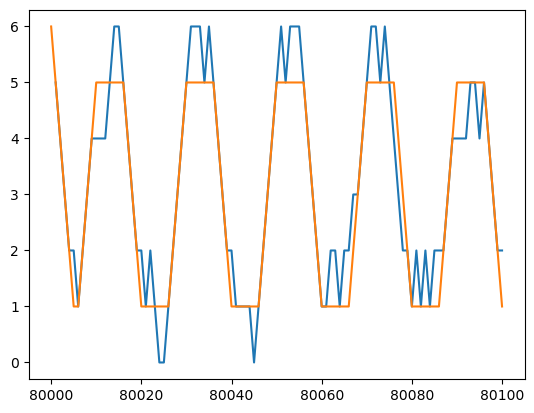

160000
160000 train done
1.2134743107489632


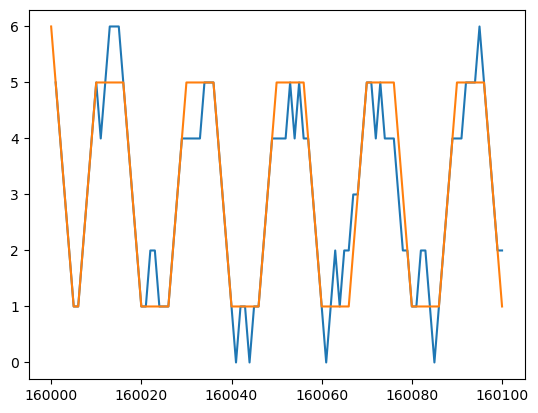

320000
320000 train done
1.2176221757729502


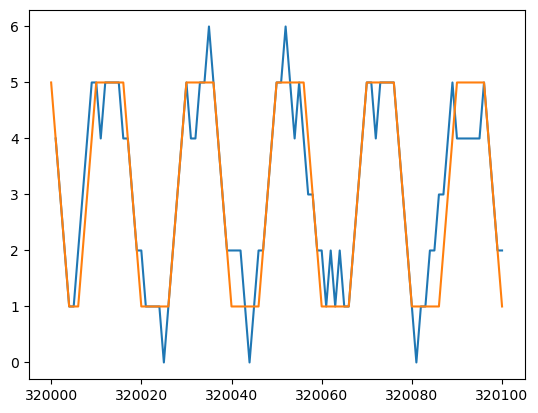

640000
640000 train done
1.154839065125666


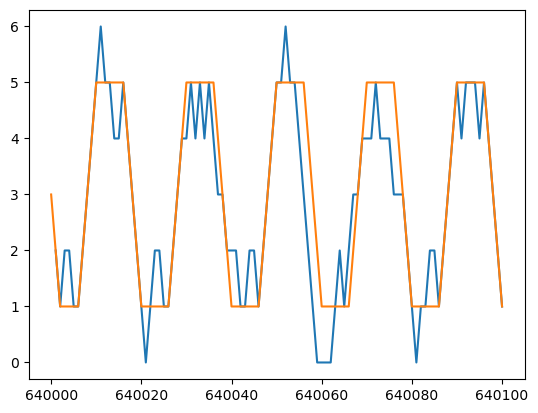

1000
1000 train done
1.6791652569744298


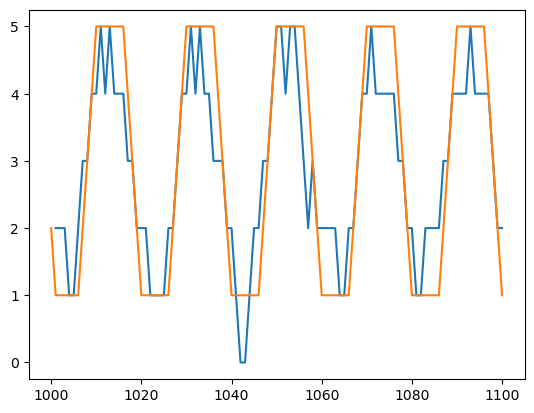

5000
5000 train done
1.4342367934492934


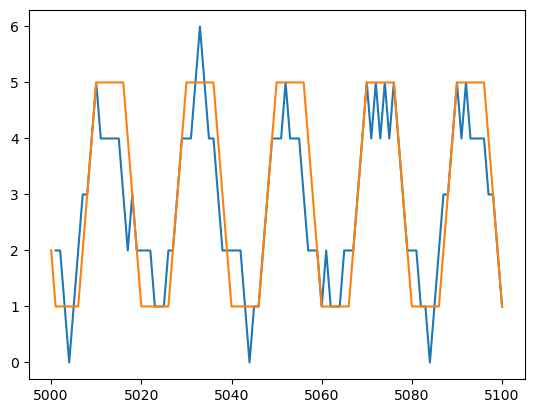

10000
10000 train done
1.3018543906735505


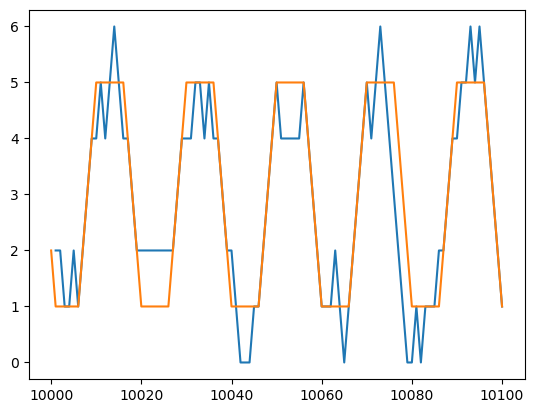

20000
20000 train done
1.267552801697069


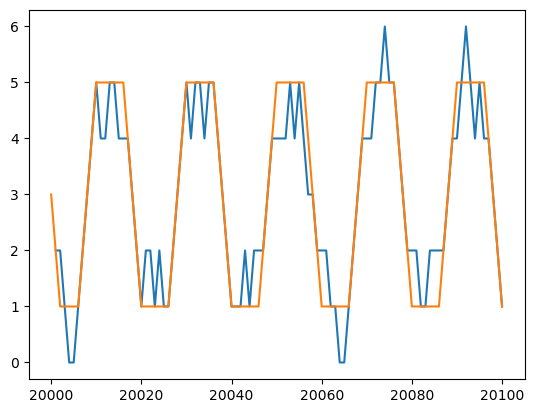

40000
40000 train done
1.6019529028865571


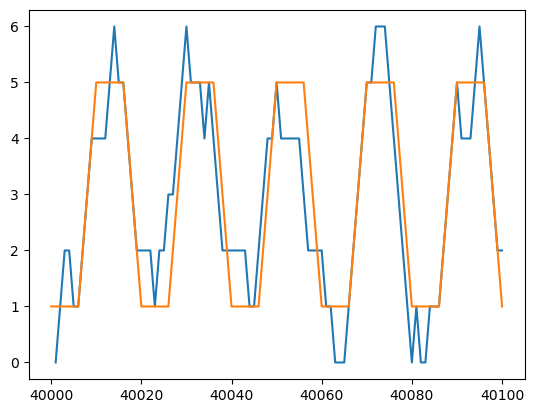

80000
80000 train done
1.3696698631723947


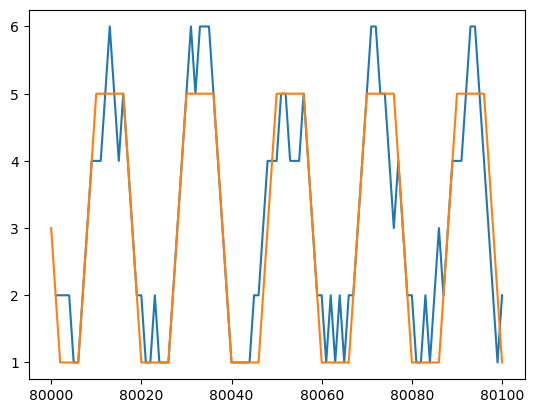

160000
160000 train done
1.2919054352273003


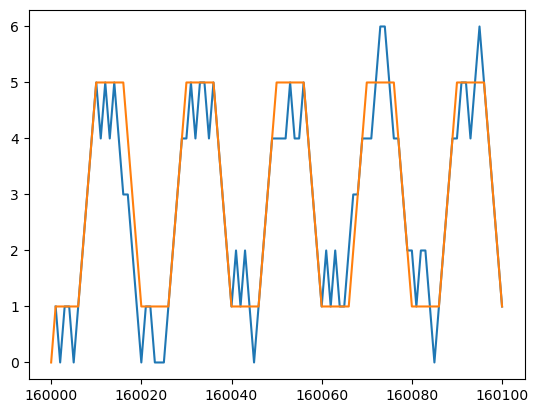

320000
320000 train done
1.5566590607863213


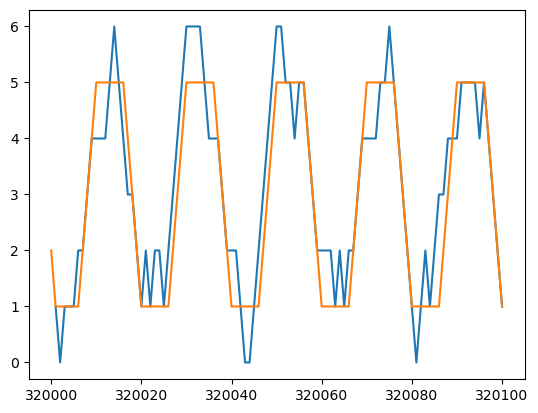

640000
640000 train done
1.3701923746067126


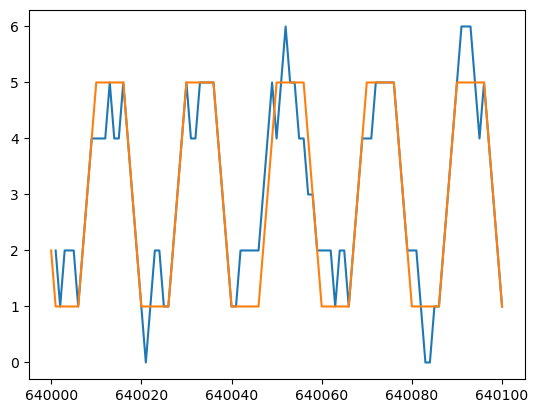

1000
1000 train done
1.3589502781674674


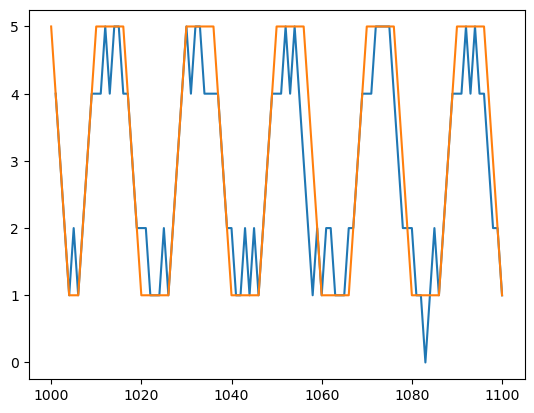

5000
5000 train done
1.4890052214718108


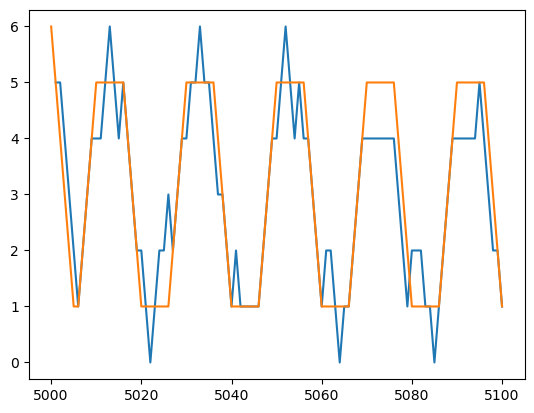

10000
10000 train done
1.5495564606642551


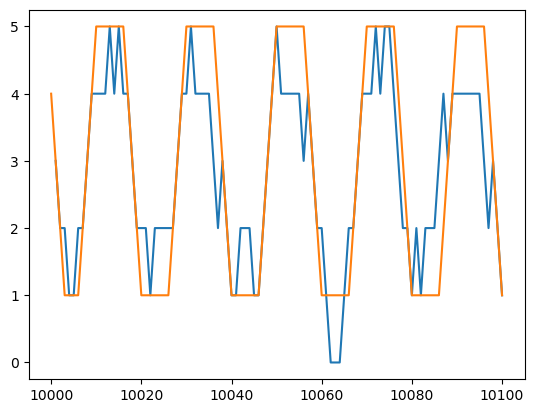

20000
20000 train done
1.679156119547113


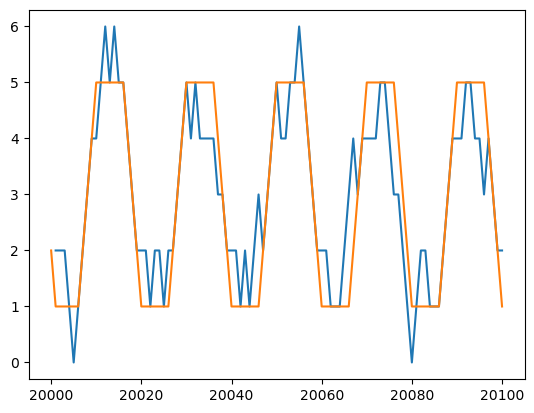

40000
40000 train done
1.4121778862877241


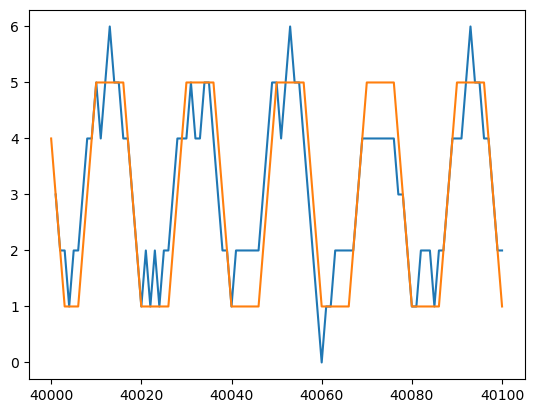

80000
80000 train done
1.5011384479909438


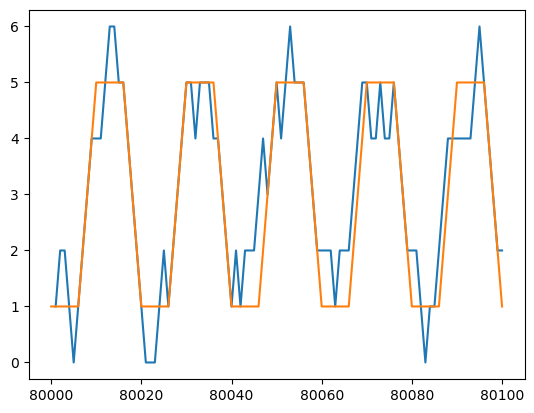

160000
160000 train done
1.4691718443109965


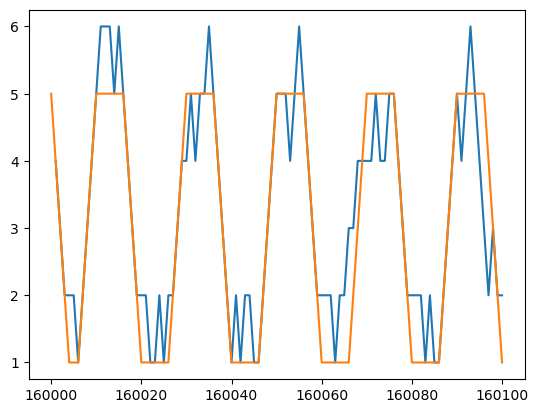

320000
320000 train done
1.3653381532262616


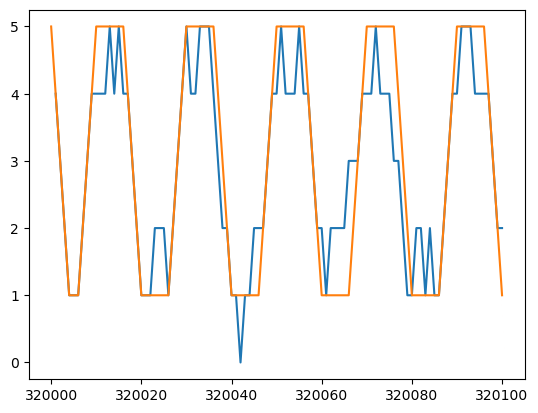

640000
640000 train done
1.059082612438911


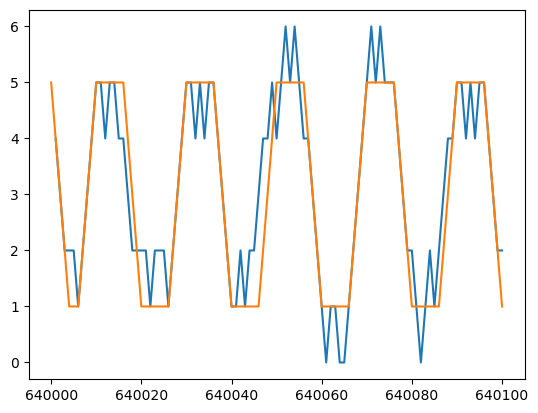

1000
1000 train done
0.966748704109566


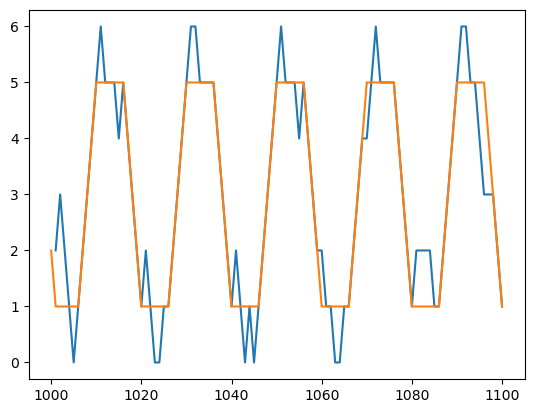

5000
5000 train done
1.204046536732307


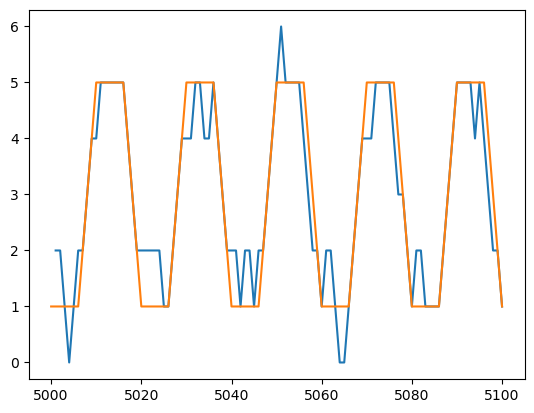

10000
10000 train done
1.3251620975591538


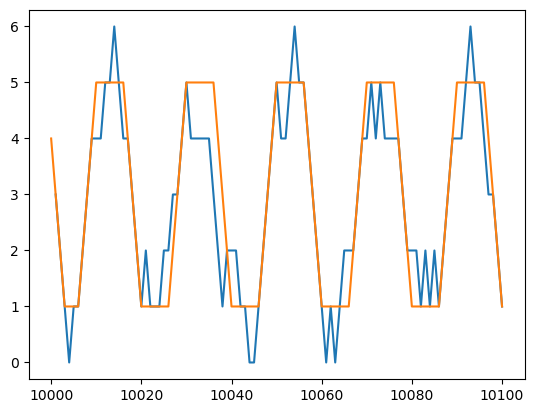

20000
20000 train done
1.6788025357557697


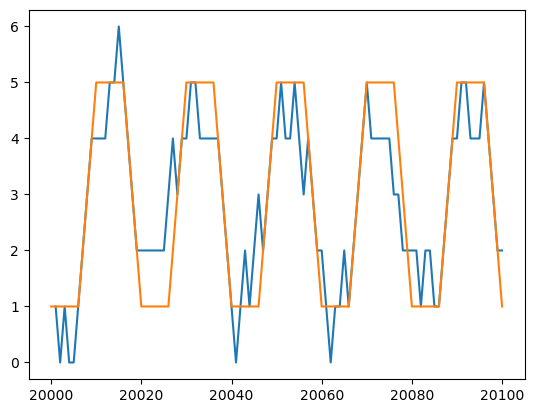

40000
40000 train done
1.4070979256016931


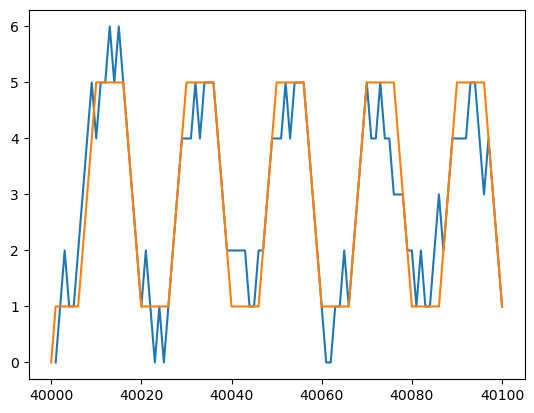

80000
80000 train done
1.6459374575143233


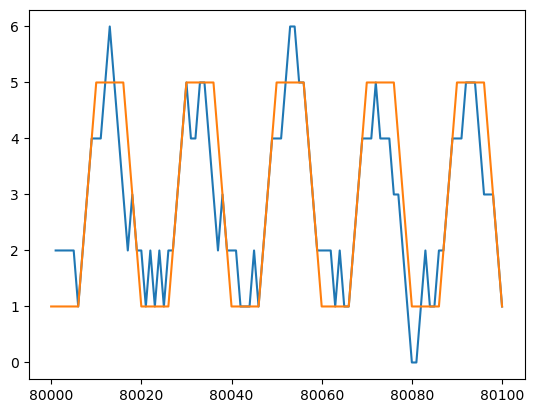

160000
160000 train done
1.2232158544353426


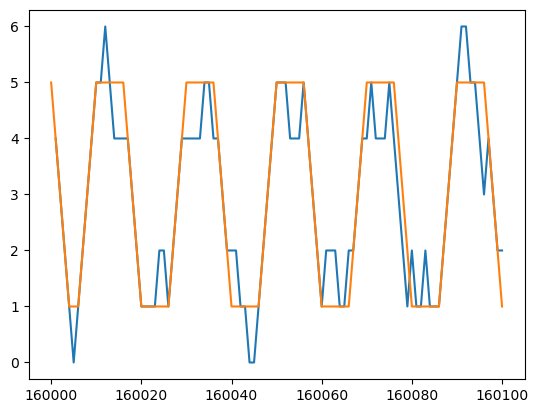

320000
320000 train done
1.0264201572924463


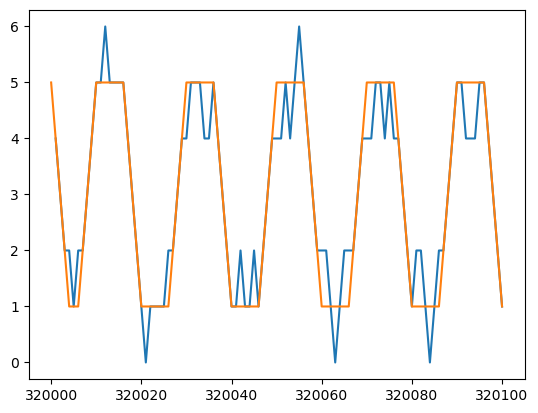

640000
640000 train done
1.1474063925535394


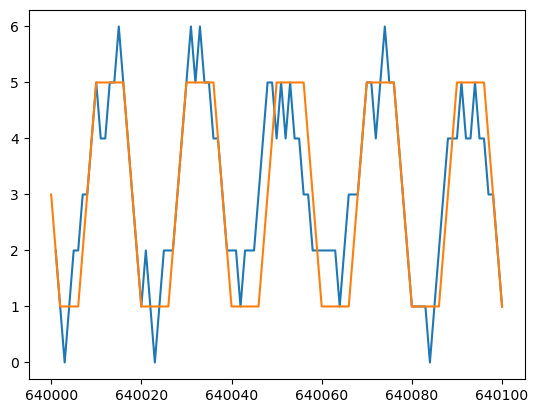

In [4]:
DELTA_t = 10
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000,160000,320000,640000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T in Ts:
        # n_seq = int(T/(DELTA_t+1))
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:])
        X_train = STATES_arr
        Y_train = REWARDS_arr
        # rf = RandomForestRegressor(n_estimators=1000, random_state=515)
        ## Using XGB regressor with delta = 1 is converging faster -- 150
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",     # or "exact" (slower, RAM heavy)
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=3000, eval_metric="rmse"
        )
        rf.fit(X_train, Y_train)
        print(T,'train done')

        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/DF/XGB_optimal_oh_w_time1000_160000_w_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



# PVFM - Onehot - RF

In [24]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in np.arange(8,10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T)
        X_train = new_state_oh[:T,:]
        Y_train = prewards[:T]
        rf= RandomForestRegressor(n_estimators=1000, random_state=1998+515+rep)
        rf.fit(X_train, Y_train)
        print(T,'train done')
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        # plt.plot(np.arange(T+1,T+101),future_states[1:])
        # plt.plot(np.arange(T,T+101),path)
        # plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/RF_oh_w_time1000_80000_wo_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
1000 train done
1.9793619167929193
training timestamps 5000
5000 train done
1.8457258934010035
training timestamps 10000
10000 train done
2.000100824459517
training timestamps 20000
20000 train done
1.8457116709516714
training timestamps 40000
40000 train done
1.6902301436014968
training timestamps 80000
80000 train done
1.2546180404630507
training timestamps 1000
1000 train done
2.3720876276825975
training timestamps 5000
5000 train done
1.954582505097526
training timestamps 10000
10000 train done
2.070300656952691
training timestamps 20000
20000 train done
2.1136919002054624
training timestamps 40000
40000 train done
1.7031685197184065
training timestamps 80000
80000 train done
1.3568396759471721


# PVFM - Onehot - XGB

In [ ]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
threshold = 1e-4
# Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T,normalization=False)
        X_train = new_state_oh[:T,:]
        Y_train = prewards[:T]
        is_pos = (Y_train > threshold).astype(int)
        pos = is_pos.sum()
        neg = len(Y_train) - pos
        w = np.where(Y_train > threshold, (neg / max(pos,1)), 1.0)
        # rf= RandomForestRegressor(n_estimators=1000, random_state=515)
        rf = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",     # or "exact" (slower, RAM heavy)
                n_jobs = -1,
                learning_rate=0.05, max_depth=10,
                subsample=1, colsample_bytree=0.8,
                n_estimators=2000, eval_metric="rmse"
            )
        
        rf.fit(X_train, Y_train,sample_weight=w)
        print(T,'train done')
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma,normalization = True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma,normalization = True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/GBT_weighted_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
1000 train done
1.887401239206694


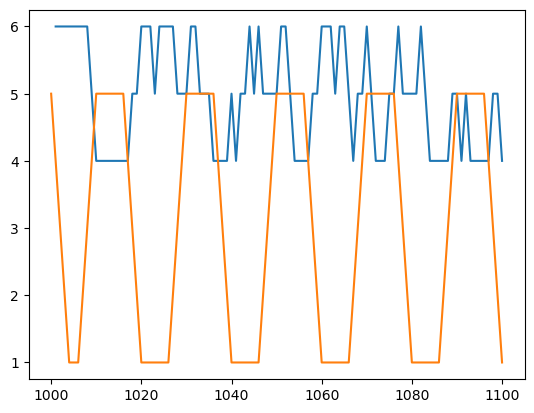

training timestamps 5000
5000 train done
1.447609766586954


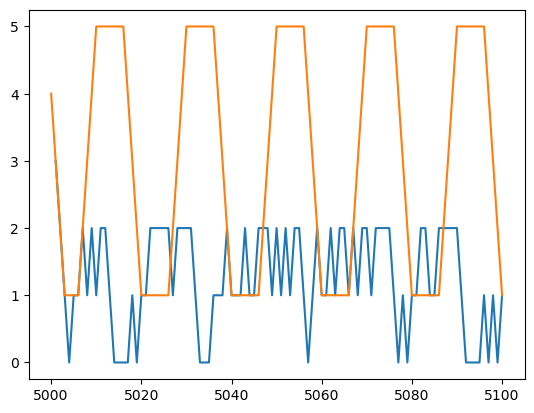

training timestamps 10000
10000 train done
2.046731678814601


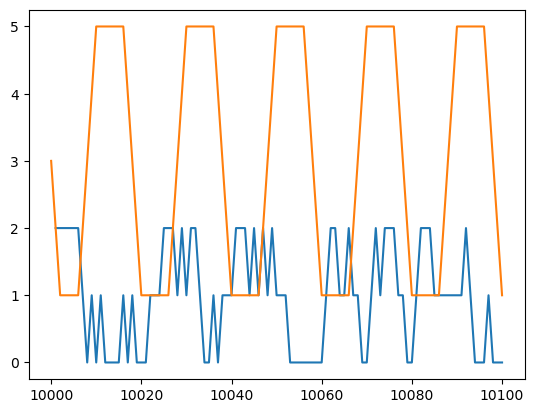

training timestamps 20000


KeyboardInterrupt: 

In [8]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
threshold = 1e-4
# Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T,normalization=False)
        X_train = new_state_oh[:T,:]
        Y_train = prewards[:T]
        is_pos = (Y_train > threshold).astype(int)
        pos = is_pos.sum()
        neg = len(Y_train) - pos
        w = np.where(Y_train > threshold, (neg / max(pos,1)), 1.0)
        rf= RandomForestRegressor(n_estimators=1000, random_state=515)
        # rf = xgb.XGBRegressor(
        #         objective="reg:squarederror",
        #         tree_method="exact",     # or "exact" (slower, RAM heavy)
        #         n_jobs = -1,
        #         learning_rate=0.05, max_depth=10,
        #         subsample=1, colsample_bytree=0.8,
        #         n_estimators=2000, eval_metric="rmse"
        #     )
        
        rf.fit(X_train, Y_train,sample_weight=w)
        print(T,'train done')
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma,normalization = True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma,normalization = True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/RF_weighted_wo_normy_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )

